# Customer Churn Analysis using the telecom-churn dataset

# Table of Contents

1.  [Inspecting Data](#Inspecting-Data)
2.  [Handling Null Values](#Handling-Null-Values)
3.  [Exploratory Data Analysis](#Exploratory-Data-Analysis)
4.  [Churn Prediction](#Churn-Prediction)
5.  [Model Evaluation](#Model-Evaluation)
6.  [Conclusions](#Conclusions)

In [35]:
# Importing libraries and downloading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve, average_precision_score)


path = kagglehub.dataset_download("barun2104/telecom-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telecom-churn' dataset.
Path to dataset files: /kaggle/input/telecom-churn


In [36]:
# First 5 rows

df = pd.read_csv(os.path.join(path, "telecom_churn.csv"))
df.head(5)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [37]:
# Last 5 rows

df.tail(5)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0
3332,0,74,1,1,3.70,0,234.4,113,100.0,13.30,13.7


# Inspecting Data

In [38]:
# Dataset info and summary statistics
df.info()
print(df.shape)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB
(3333, 11)


,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


# Handling Null Values

In [39]:
# Checking for null values
df.isnull().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


# Exploratory Data Analysis

In [40]:
# Plot styling
sns.set_style('whitegrid')
palette = ['#4C72B0', '#DD8452']
model_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#E377C2']
metric_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

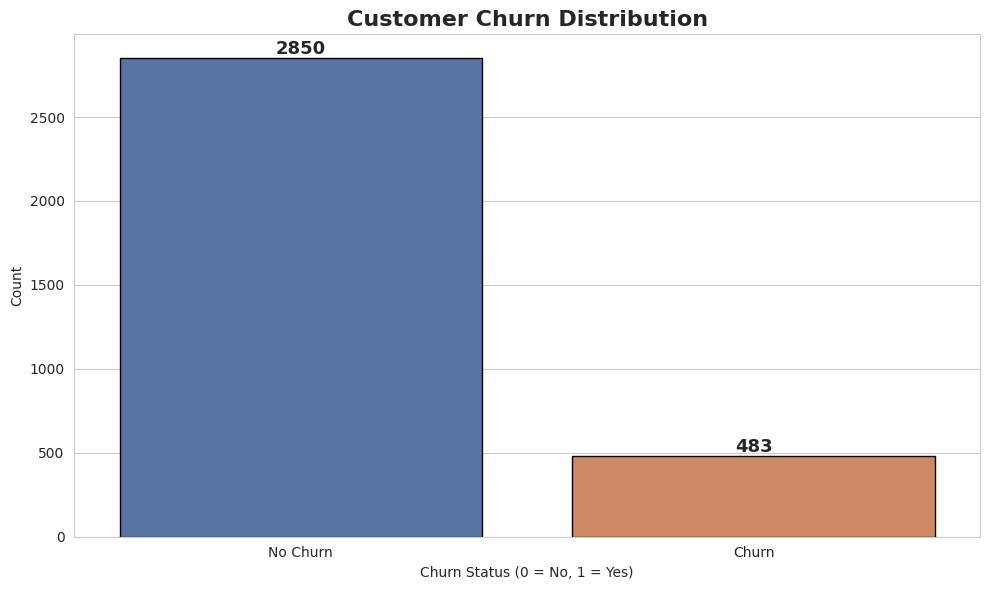

In [41]:
# Churn distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette=palette, legend=False, edgecolor='black')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

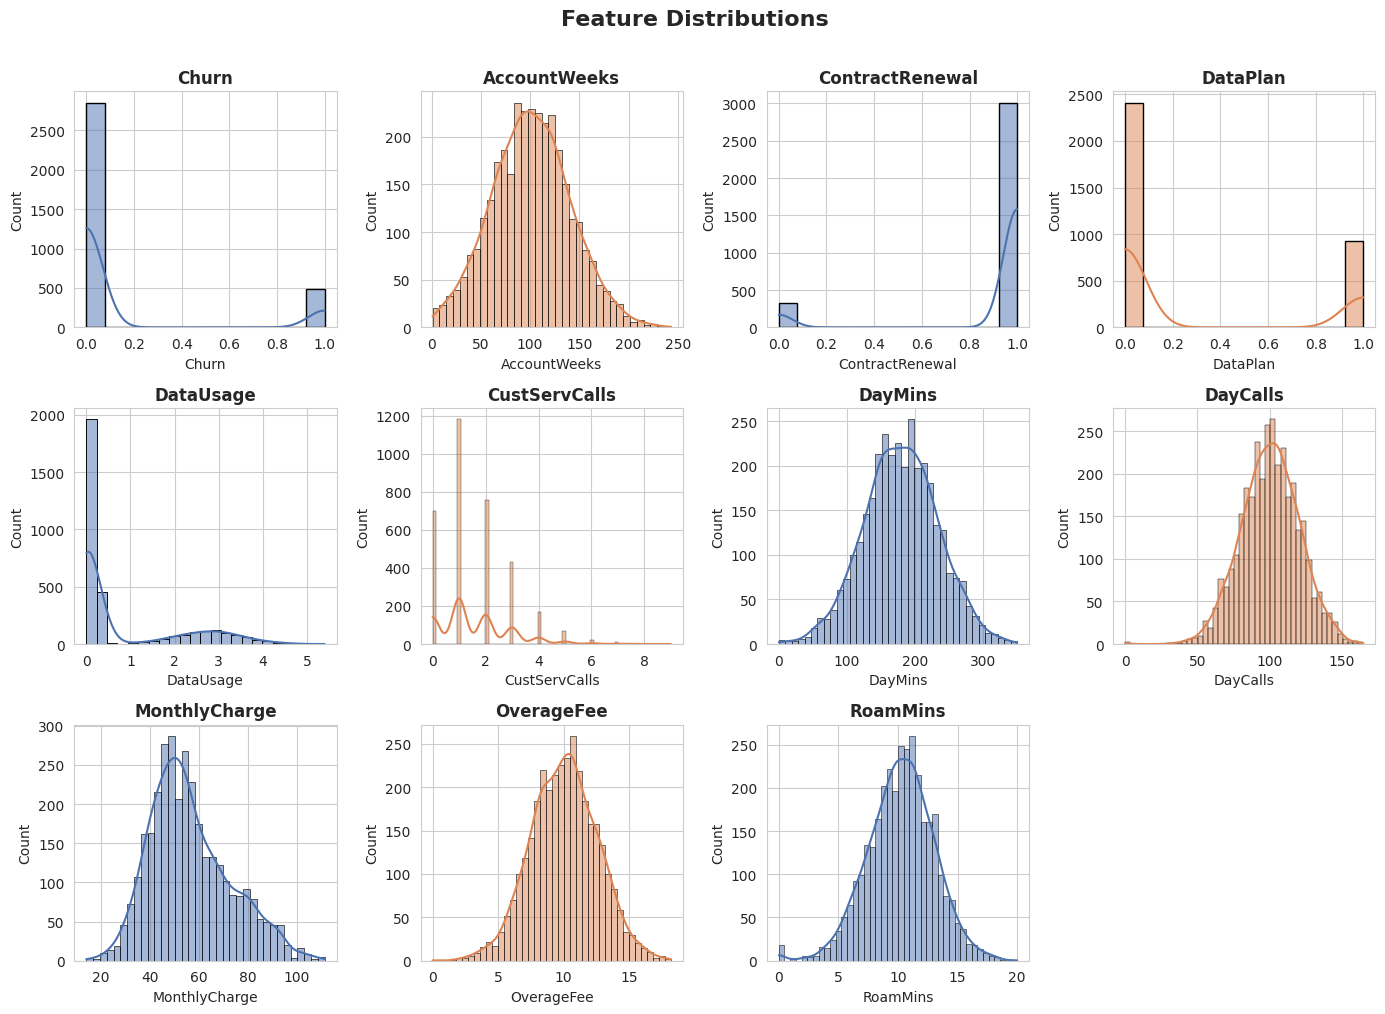

In [42]:
# Feature distributions
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i // 4][i % 4], color=palette[i % 2], kde=True, edgecolor='black')
    axes[i // 4][i % 4].set_title(col, fontweight='bold')
axes[2][3].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

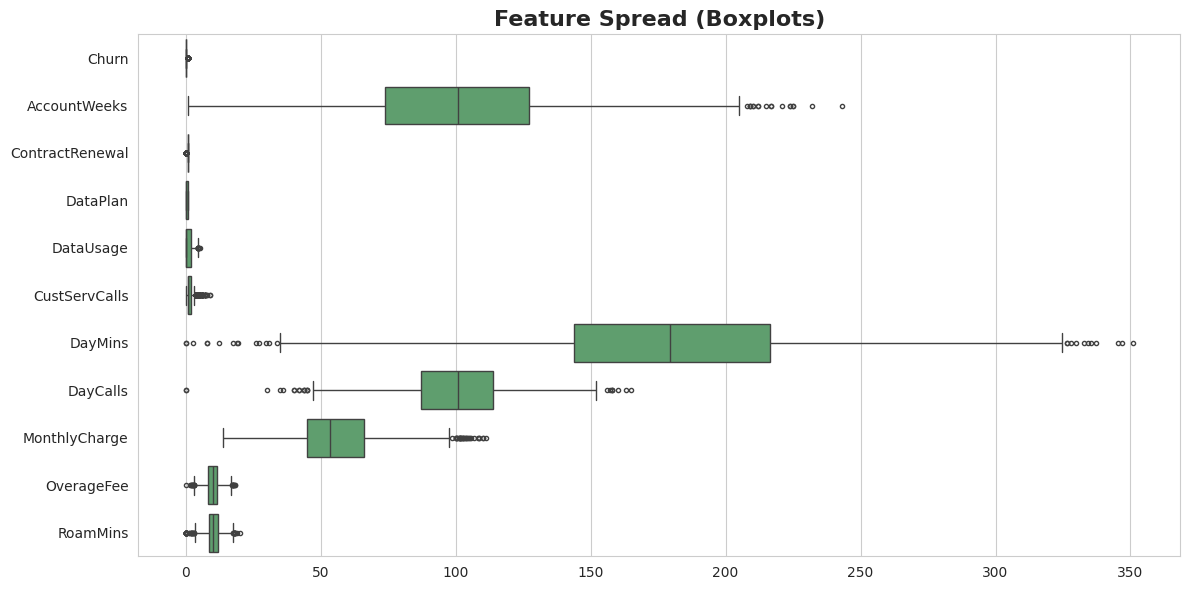

In [43]:
# Feature spread (boxplots)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient='h', color='#55A868', flierprops=dict(marker='o', markersize=3))
plt.title('Feature Spread (Boxplots)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

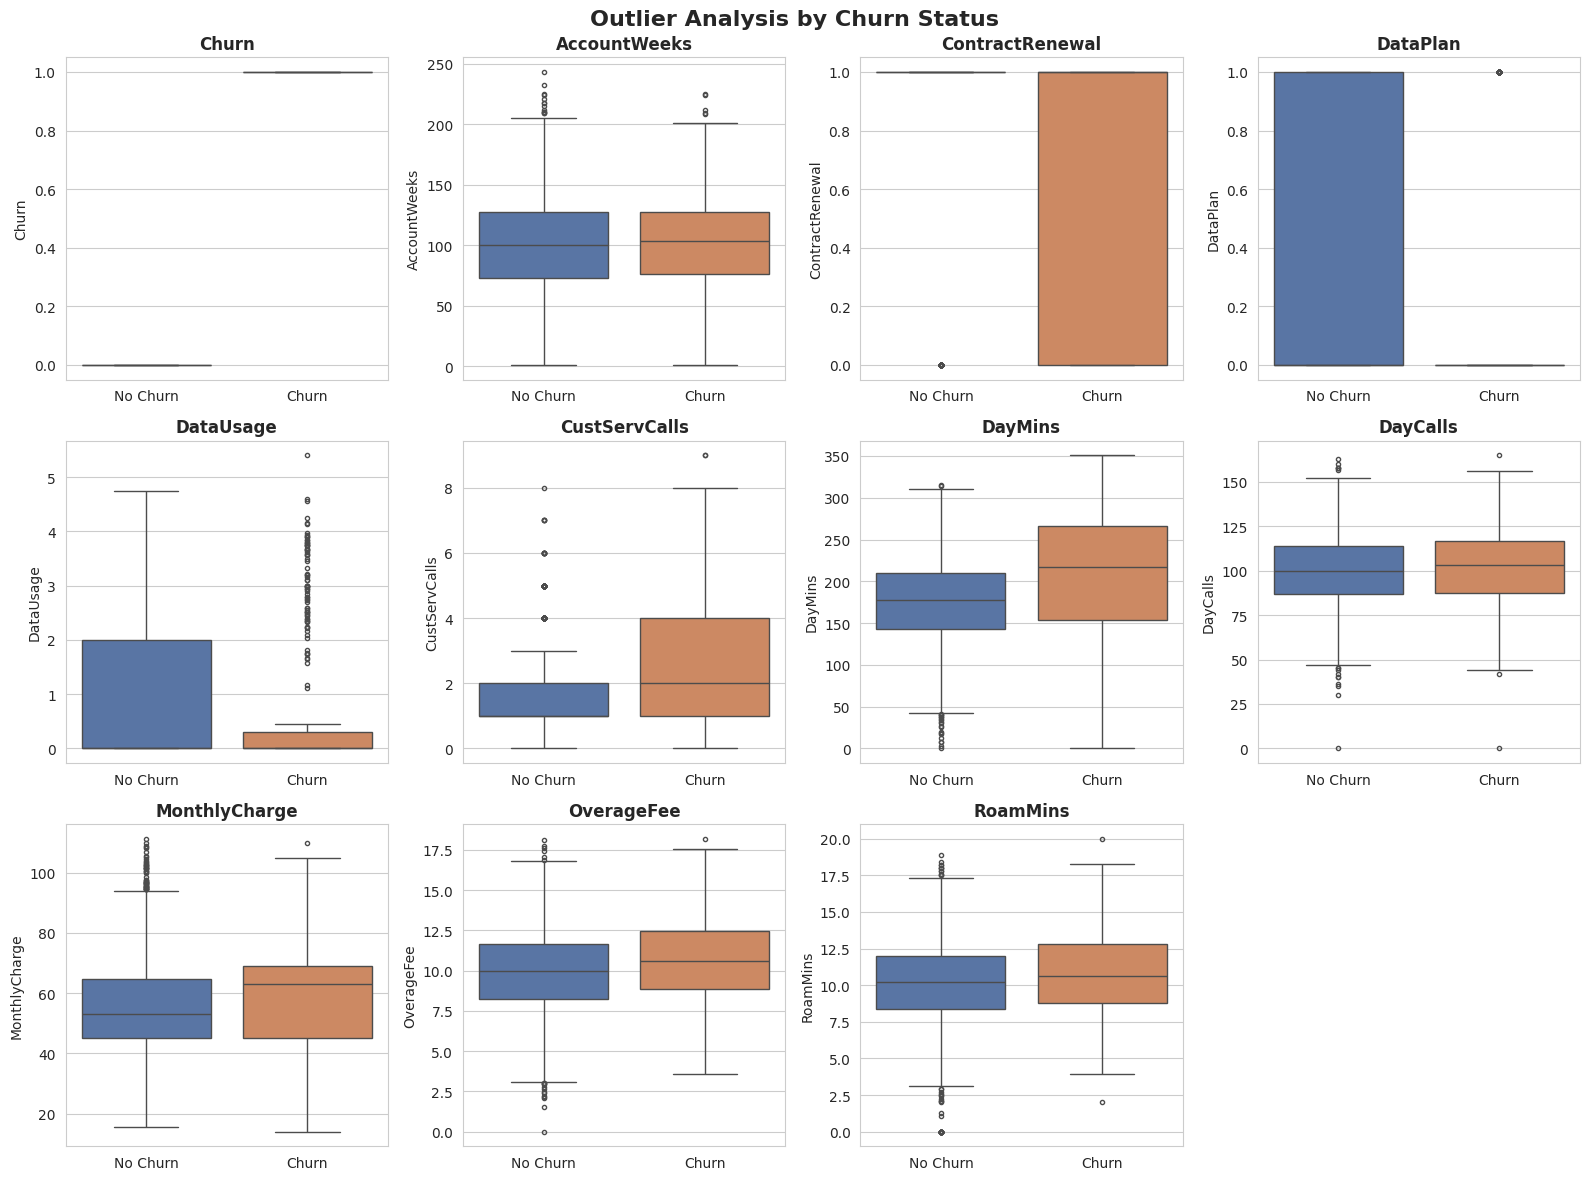

In [44]:
# Outlier analysis by churn status
numeric_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i // 4][i % 4],
                hue='Churn', legend=False, palette=palette, flierprops=dict(marker='o', markersize=3))
    axes[i // 4][i % 4].set_title(col, fontweight='bold')
    axes[i // 4][i % 4].set_xticks([0, 1])
    axes[i // 4][i % 4].set_xticklabels(['No Churn', 'Churn'])
    axes[i // 4][i % 4].set_xlabel('')
axes[2][3].set_visible(False)
plt.suptitle('Outlier Analysis by Churn Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

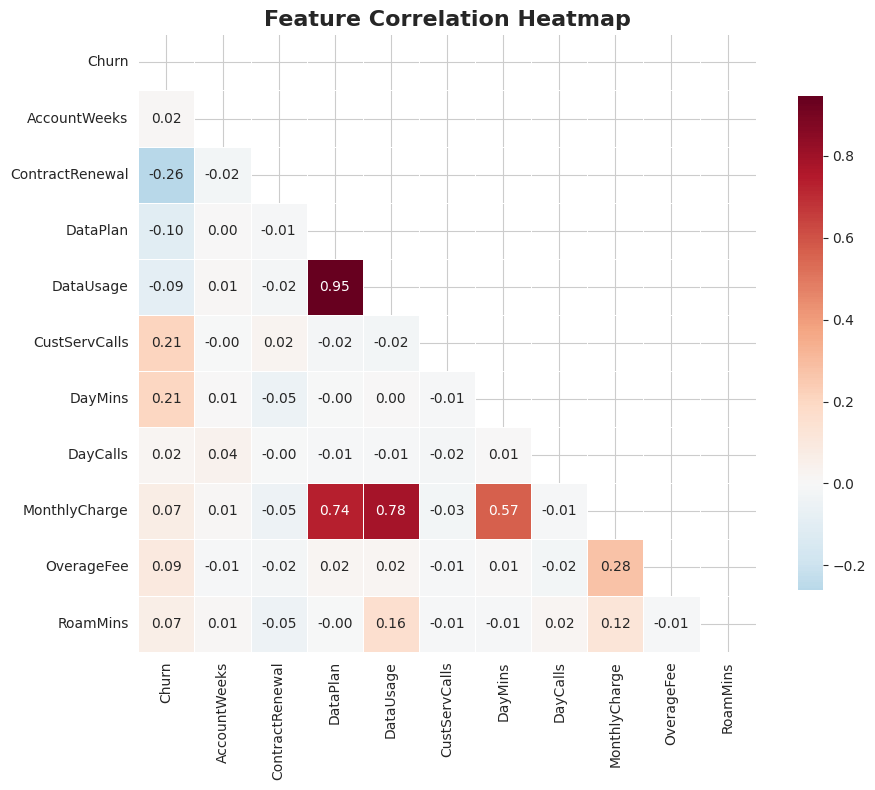

In [45]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

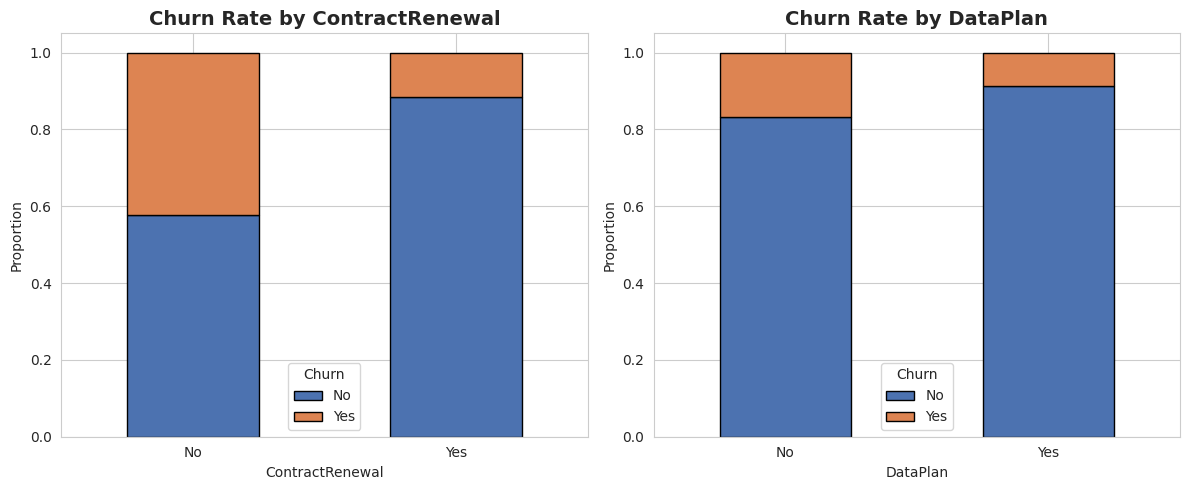

In [46]:
# Churn rate by categorical features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['ContractRenewal', 'DataPlan']):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=palette, edgecolor='black')
    ax.set_title(f'Churn Rate by {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(['No', 'Yes'], rotation=0)
    ax.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

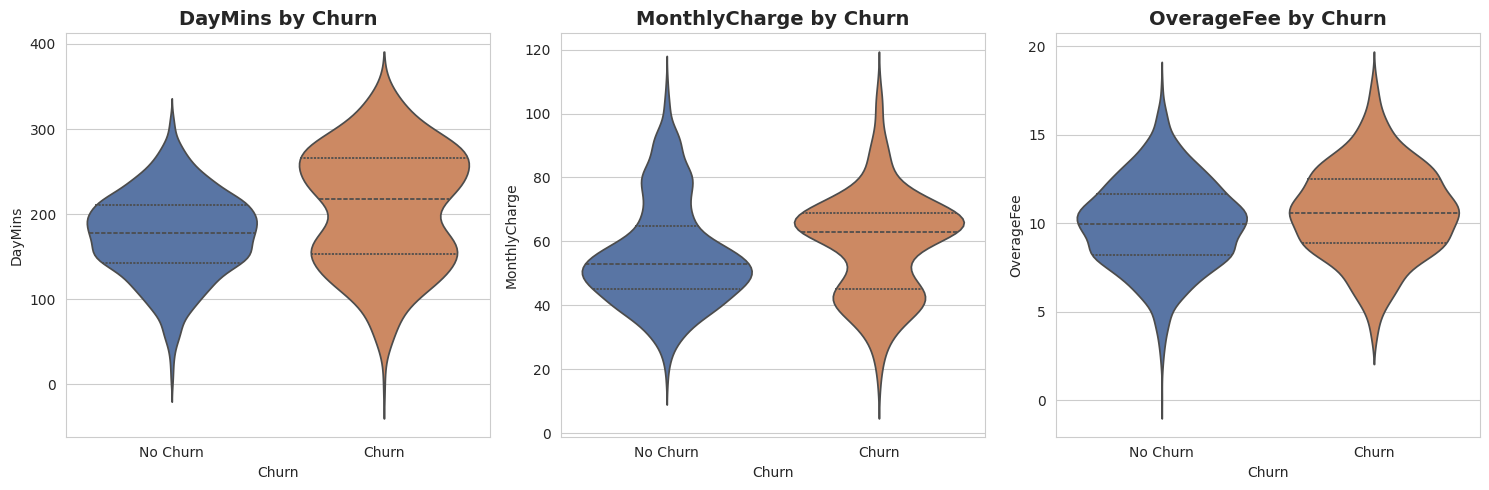

In [47]:
# Key features by churn status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['DayMins', 'MonthlyCharge', 'OverageFee']):
    sns.violinplot(x='Churn', y=col, data=df, ax=ax, hue='Churn', legend=False, palette=palette, inner='quartile')
    ax.set_title(f'{col} by Churn', fontsize=14, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

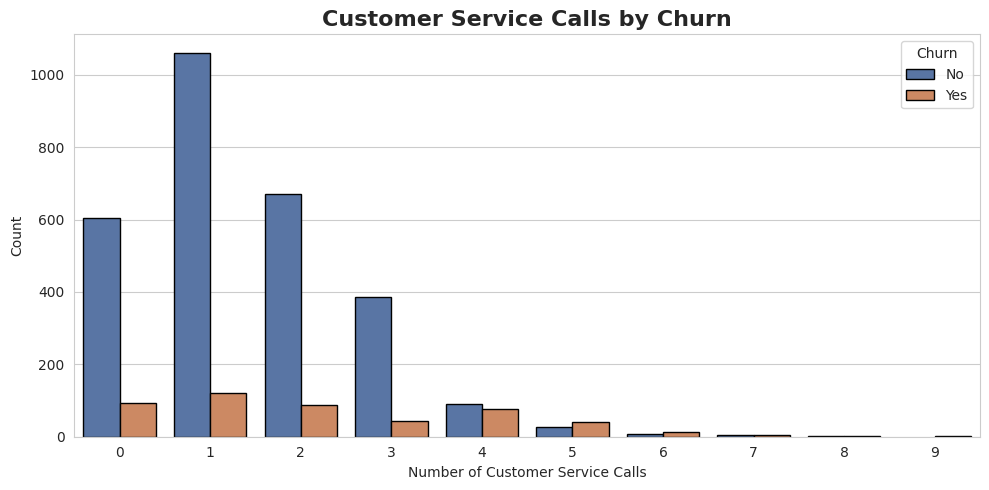

In [48]:
# Customer service calls vs churn
plt.figure(figsize=(10, 5))
sns.countplot(x='CustServCalls', hue='Churn', data=df, palette=palette, edgecolor='black')
plt.title('Customer Service Calls by Churn', fontsize=16, fontweight='bold')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Count')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Churn Prediction

Stratified split, scaler fit on train only, models scored on precision, recall, F1 and ROC-AUC (churn is the minority class).

In [49]:
# Stratified train/test split and scaling (fit on train only)
X = df.drop('Churn', axis=1)
y = df['Churn']
feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit on train only -> no leakage
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}')

Train: (2666, 10) | Test: (667, 10)
Churn rate -> train: 0.145 | test: 0.145


In [50]:
# Defining and training the models
models = {
    'Logistic':      LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost':      AdaBoostClassifier(random_state=42),
    'HistGB':        HistGradientBoostingClassifier(random_state=42),
    'MLP':           MLPClassifier(max_iter=1000, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} fitted.')

Logistic fitted.
Decision Tree fitted.
Random Forest fitted.
AdaBoost fitted.
HistGB fitted.
MLP fitted.


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [51]:
# Tuning Random Forest with GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print(f'Best CV ROC-AUC: {grid.best_score_:.4f}')

models['RF (Tuned)'] = grid.best_estimator_

Best params: {'max_depth': 5, 'n_estimators': 50}
Best CV ROC-AUC: 0.9206


In [52]:
# Test predictions and metric scores
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic,0.8576,0.5263,0.2062,0.2963,0.8091
Decision Tree,0.8921,0.6404,0.5876,0.6129,0.7657
Random Forest,0.9250,0.8219,0.6186,0.7059,0.8603
AdaBoost,0.8711,0.6078,0.3196,0.4189,0.8509
HistGB,0.9295,0.8289,0.6495,0.7283,0.8545
MLP,0.9070,0.7011,0.6289,0.6630,0.8672
RF (Tuned),0.9190,0.8644,0.5258,0.6538,0.8803


# Model Evaluation

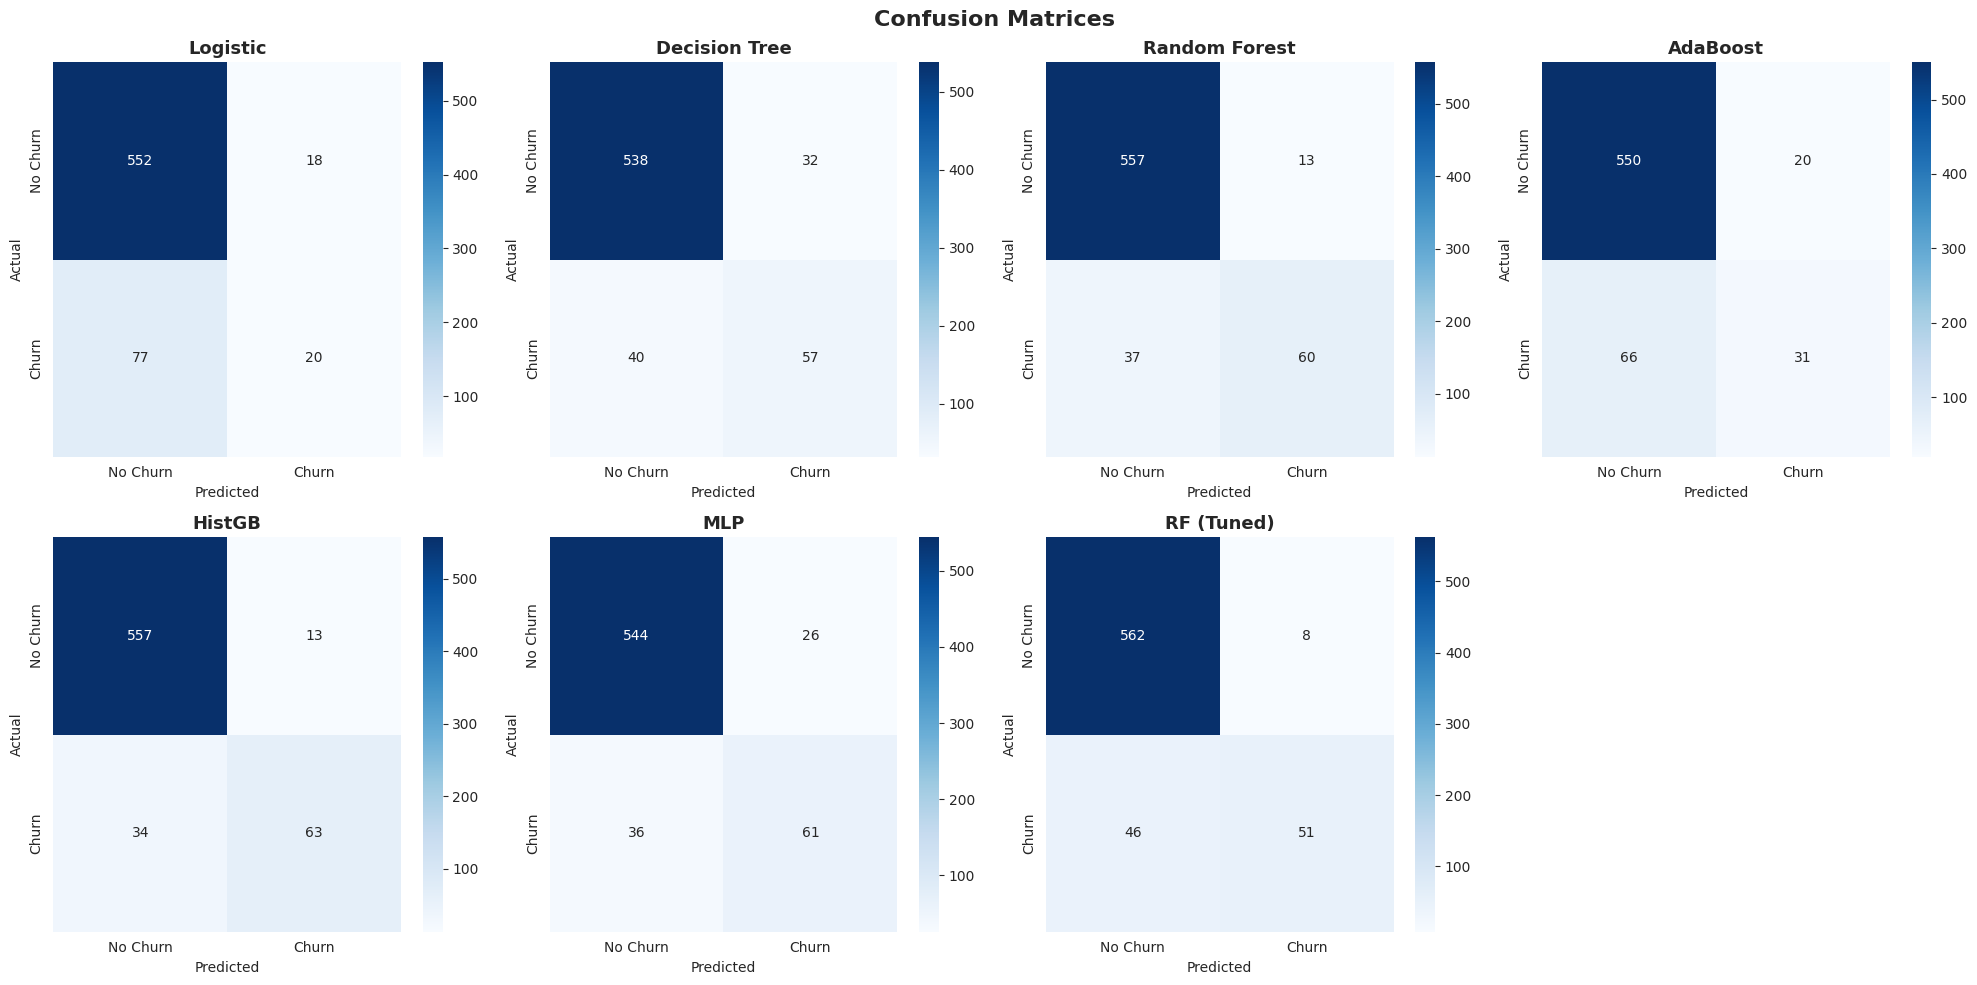

In [53]:
# Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
axes.flatten()[-1].set_visible(False)
plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

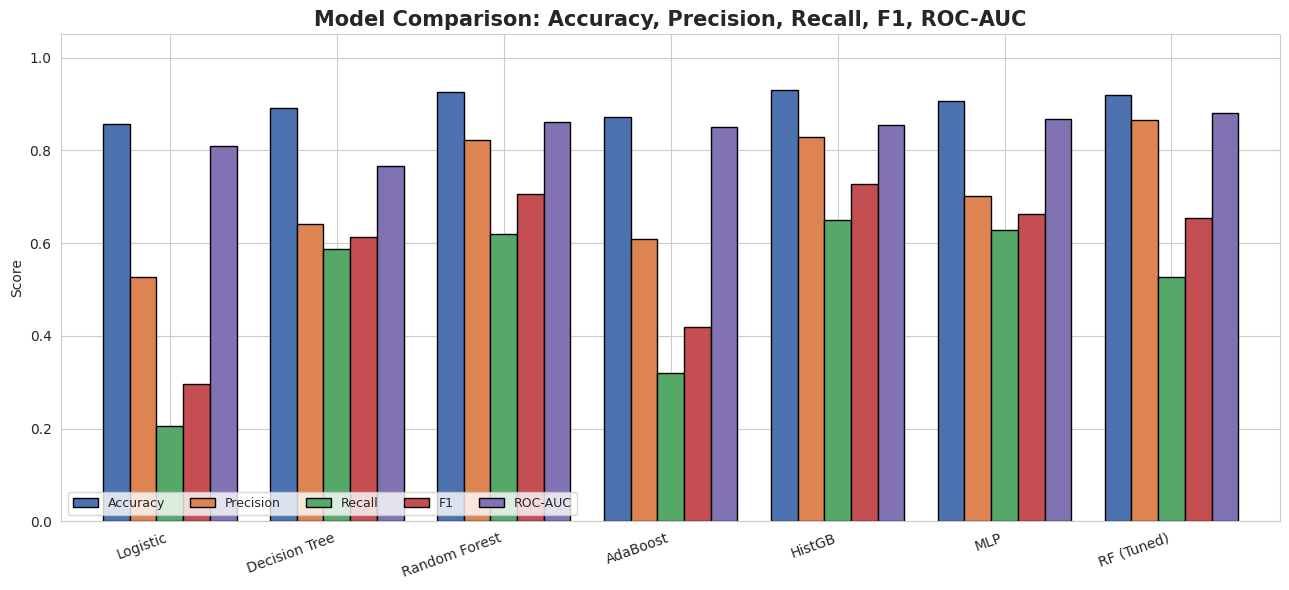


Best model by F1: HistGB
Best model by ROC-AUC: RF (Tuned)


In [54]:
# Metric comparison across models
ax = results_df.plot(kind='bar', figsize=(13, 6), width=0.8,
                     color=metric_palette, edgecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, F1, ROC-AUC',
             fontsize=15, fontweight='bold')
ax.legend(loc='lower left', ncol=5, fontsize=9)
ax.set_xticklabels(results_df.index, rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(f"\nBest model by F1: {results_df['F1'].idxmax()}")
print(f"Best model by ROC-AUC: {results_df['ROC-AUC'].idxmax()}")

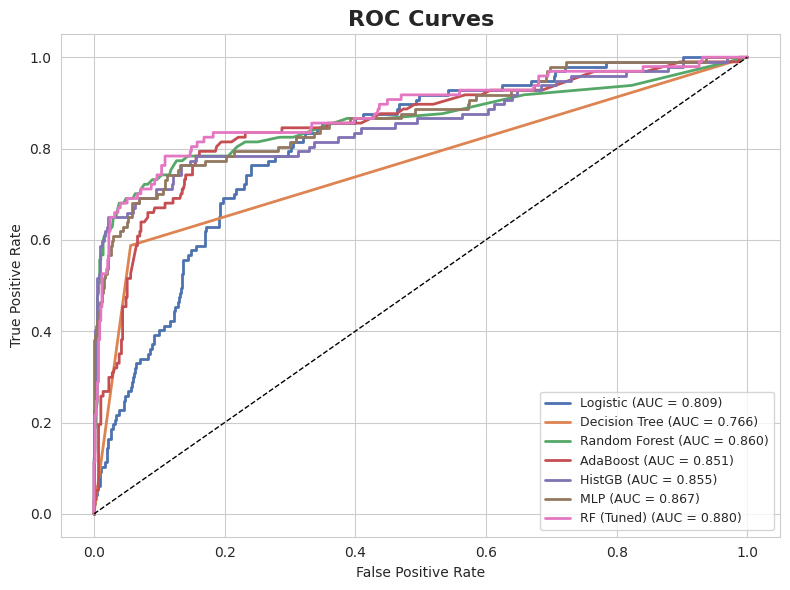

In [55]:
# ROC curves
plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), model_palette):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Precision-Recall Curves

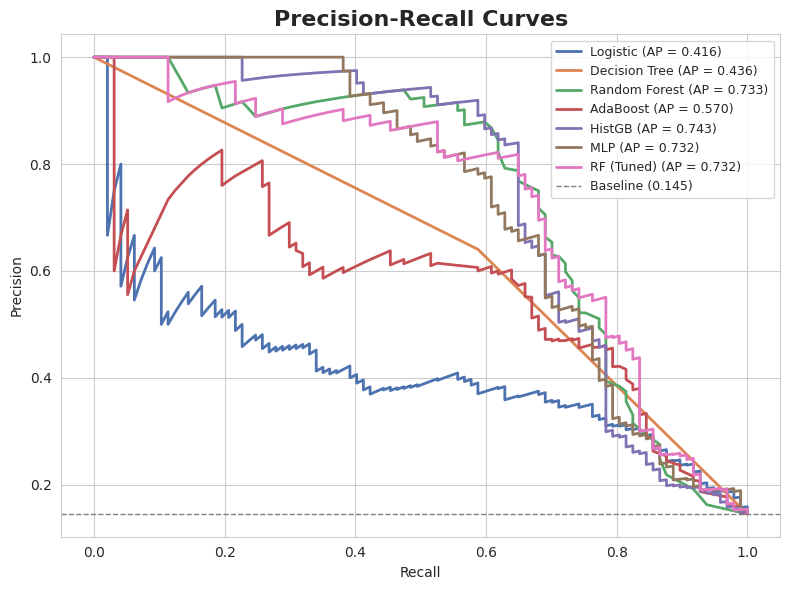

In [56]:
# Precision-recall curves
plt.figure(figsize=(8, 6))
for (name, model), color in zip(models.items(), model_palette):
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP = {ap:.3f})')
baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--', linewidth=1,
            label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## Classification Report (Best Model by F1)

In [57]:
# Classification report for the best model
best_name = results_df['F1'].idxmax()
best_model = models[best_name]
y_pred_best = best_model.predict(X_test)

print(f'Best model by F1: {best_name}\n')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Best model by F1: HistGB

              precision    recall  f1-score   support

    No Churn       0.94      0.98      0.96       570
       Churn       0.83      0.65      0.73        97

    accuracy                           0.93       667
   macro avg       0.89      0.81      0.84       667
weighted avg       0.93      0.93      0.93       667



## Feature Importance (Random Forest)

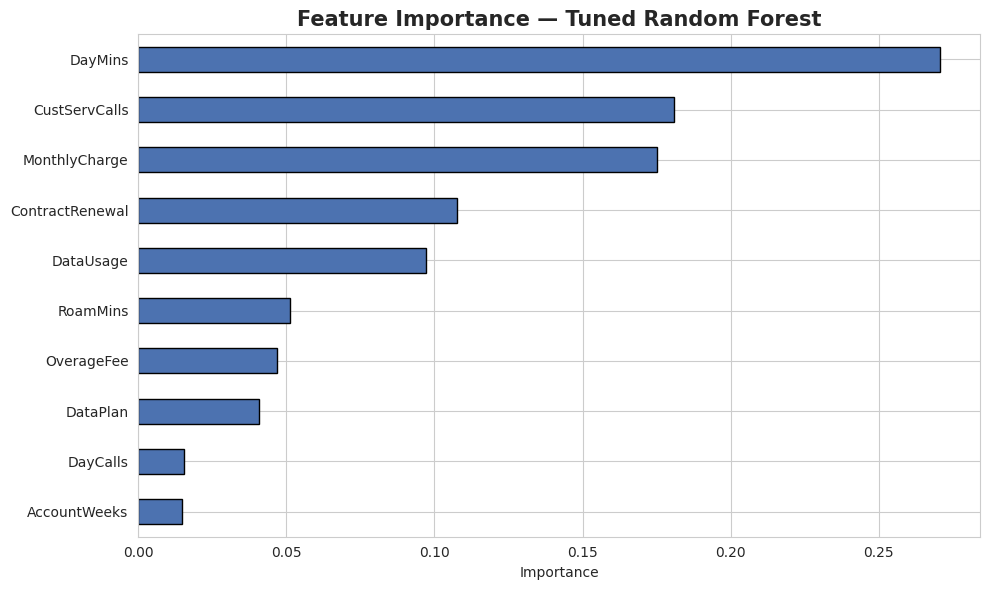

In [58]:
# Feature importance from the tuned Random Forest
importances = pd.Series(models['RF (Tuned)'].feature_importances_, index=feature_names)
importances = importances.sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#4C72B0', edgecolor='black')
plt.title('Feature Importance — Tuned Random Forest', fontsize=15, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Conclusions

- Churn is imbalanced (~14%), so recall and F1 matter more than accuracy.
- Best models: Random Forest (F1) and RF Tuned (ROC-AUC).
- Top churn drivers: DayMins, MonthlyCharge, CustServCalls, ContractRenewal.
- Action: target high-usage customers with 3+ service calls and no recent contract renewal.